# Project 2:
### Extension 1 Cardiovascular Diseases

## Notebook 1: Exploratory Data Analysis — Cardiovascular Diseases

---
**Author:** Niral Patel  
**Dataset:** Cardiovascular Disease dataset (From: Svetlana Ulianova)  
**Source:** [Kaggle - Dataset Cardiovascular Disease](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset/data)  
**Records:** 70000 patient x 12 features  
**Objective:** Predict Cardiovascular risk using blood pressure, Cholesterol, smoking, and physical health.   

---
All of the dataset values were collected at the moment of medical examination.

## 1. Standard imports

In [1]:
#Standard imports

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from src.logger import logger
from src.exception import CustomException

#Display setting
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

#plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('All imports done')
print(f"pandas    :{pd.__version__}")
print(f"Numpy     :{np.__version__}")

All imports done
pandas    :2.3.3
Numpy     :2.4.3


## 2. Load Dataset and First Inspection

In [2]:
df = pd.read_csv("../notebook/data/cardio_train.csv", sep=';')

In [3]:
# Drop id, convert the age to years
df['age'] = (df['age'] / 365).round()
df = df.drop(columns= ['id'])

logger.info("Dropped id column, converted age to years")
print(df['age'].describe())

[03-19-2026 15:45:13] "cardiovascular" Line:5 File:src.logger - INFO - Dropped id column, converted age to years
count   70000.00
mean       53.34
std         6.77
min        30.00
25%        48.00
50%        54.00
75%        58.00
max        65.00
Name: age, dtype: float64


In [4]:
# -- Basic shape and information of the dataset
print("="*50)
print("Cardiovascular Disease dataset - First look")
print("="*50)

print(f"\nShape:             {df.shape[0]:,} rows x {df.shape[1]} columns")

print("\n-- Column names and Datatypes -----------------------")
print(df.dtypes)

print("\n-- First 5 Rows -------------------------------------")
df.head()
df.info()

print("\n-- Data describe -----------------------------------")
df.describe().T

Cardiovascular Disease dataset - First look

Shape:             70,000 rows x 12 columns

-- Column names and Datatypes -----------------------
age            float64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

-- First 5 Rows -------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 

,count,mean,std,min,25%,50%,75%,max
age,70000.00,53.34,6.77,30.00,48.00,54.00,58.00,65.00
gender,70000.00,1.35,0.48,1.00,1.00,1.00,2.00,2.00
height,70000.00,164.36,8.21,55.00,159.00,165.00,170.00,250.00
weight,70000.00,74.21,14.40,10.00,65.00,72.00,82.00,200.00
ap_hi,70000.00,128.82,154.01,-150.00,120.00,120.00,140.00,16020.00
ap_lo,70000.00,96.63,188.47,-70.00,80.00,80.00,90.00,11000.00
cholesterol,70000.00,1.37,0.68,1.00,1.00,1.00,2.00,3.00
gluc,70000.00,1.23,0.57,1.00,1.00,1.00,1.00,3.00
smoke,70000.00,0.09,0.28,0.00,0.00,0.00,0.00,1.00
alco,70000.00,0.05,0.23,0.00,0.00,0.00,0.00,1.00



---
## 📖 Data Dictionary

> **Source:** [Kaggle - Dataset Cardiovascular Disease](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset/data) All of the dataset values were collected at the moment of medical examination.

---

### Features:
| Full Name | Description | Column | DataType |
|--------|-------------|-----|-------|
|Age | Objective Feature | age | int (years)   
|Height | Objective Feature | height | int (cm) |   
|Weight | Objective Feature | weight | float (kg) |   
|Gender | Objective Feature | gender | categorical code |   
|Systolic blood pressure | Examination Feature | ap_hi | int |   
|Diastolic blood pressure | Examination Feature | ap_lo | int |   
|Cholesterol | Examination Feature | cholesterol | 1: normal, 2: above normal, 3: well above normal |   
|Glucose | Examination Feature | gluc | 1: normal, 2: above normal, 3: well above normal |   
|Smoking | Subjective Feature | smoke | binary |   
|Alcohol intake | Subjective Feature | alco | binary |   
|Physical activity | Subjective Feature | active | binary |   
|Presence or absence of cardiovascular disease | Target Variable | cardio | binary |   

### 🎯 Target Variable

| Column | Values | Description |
|--------|--------|-------------|
| `cardio` | 0 / 1 | 0 = No Disease, 1 = Has cardiovascular disease |

---

### ✅ Objective Features (measured by doctors):

| Column | Description |
|--------|-------------|
| `age` | patient age (Converted form days -> years) |
| `height` | Measurement in cm |
| `weight` | Measurement in kg |
| `gender` | 1 =Female, 2=Male |
| `ap_hi` | Systolic blood pressure  (upper number) |
| `ap_lo` | Diastolic blood pressure (lower number) |

---

### SUBJECTIVE FEATURES (reported by patient):

| Column | Description |
|--------|-------------|
| `cholesterol` | 1=Normal, 2=Above normal, 3=Well above normal |
| `gluc` | 1=Normal, 2=Above normal, 3=Well above normal |
| `smoke` | 0=No, 1=Yes |
| `alco` | 0=No, 1=Yes (alcohol consumption) |
| `active` | 0=No, 1=Yes (physical activity) |

---

### 📊 ENGINEERED (we will create):

| Column | Range | Description |
|--------|-------|-------------|
| `BMI` | calculated | Body Mass Index will calculate using weight(kg) / height(m)² (Underweight <18.5, Normal 18.5-24.9, Overweight 25-29.9, Obese 30+) |   
| `age_group` | 1-3 | Young(<45), Middle(45-55), Senior(55+) |    
| `bp_category` | 1–5 | Normal/Elevated/High1/High2/Crisis (based on ap_hi + ap_lo combined) |     
| `pulse_pressure` | int |  ap_hi - ap_lo (clinical marker) |      

---

### 🔢 Categorical Features (Encoded as Numbers)

**bp_category** — Doctor check ap_hi and ap_low

| Value | Meaning |
|-------|---------|
| 1 | Normal |
| 2 | Elevated |
| 3 | High1 |
| 4 | High2 |
| 5 | Crisis |

**Age** — Age Group Categories (1–13)

| Value | Age Group | 
|-------|-----------|
| 1 | Young(<45) |
| 2 | Middle(45-55) |
| 3 | Senior(55+) |


**cholesterol,gluc** — Both have same catagory

| Value | Meaning |
|-------|---------|
| 1 | Normal |
| 2 | Above normal |
| 3 | Well above normal |

---


In [5]:
# ==================================================
# Cell 3: Missing Values + Class Balance
# ==================================================

print("="*55)
print(" Missing value Analysis")
print("="*55)

missing = df.isnull().sum()
print(f"\n Total missing values: {missing.sum()}")
print(f" Completeness : {100 - missing.sum()/(df.size)*100:.2f}%")

print("\n"+"=" * 55)
print(" Class Balance Analysis")
print("=" * 55)

counts = df['cardio'].value_counts()
print(f"\n No Disease : {counts[0]:,} ({counts[0]/len(df)*100:.1f})%")
print(f" Disease      : {counts[1]:,} ({counts[1]/len(df)*100:.1f})%")
print(f" ratio        : {counts[0]/counts[1]:.2f}:1")

print("\n Key Insight:")
if abs(counts[0]-counts[1]) / len(df) < 0.05:
    print(" Dataset is Balanced - SMOTE is not require")
    print(" We can directly train without resampling")
else:
    print(" Dataset is IMBALANCED — consider SMOTE")
    

 Missing value Analysis

 Total missing values: 0
 Completeness : 100.00%

 Class Balance Analysis

 No Disease : 35,021 (50.0)%
 Disease      : 34,979 (50.0)%
 ratio        : 1.00:1

 Key Insight:
 Dataset is Balanced - SMOTE is not require
 We can directly train without resampling


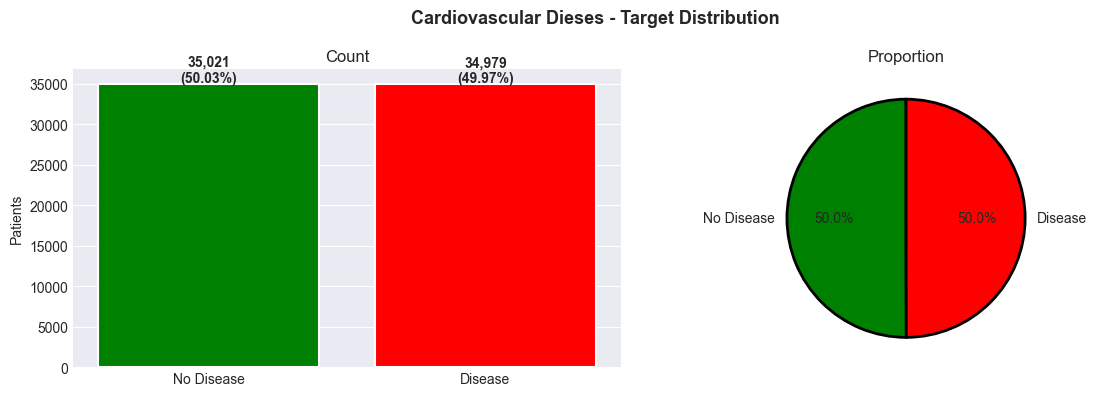

In [6]:
# ── Visualize ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fig.suptitle('Cardiovascular Dieses - Target Distribution', fontsize=13, fontweight='bold')
color = ['green', 'red']
labels = ['No Disease', 'Disease']

axes[0].bar(labels, counts.values, color=color, edgecolor='white', linewidth=1.5)
axes[0].set_title('Count')
axes[0].set_ylabel('Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.2f}%)', ha='center', fontweight='bold')


axes[1].pie(counts.values, labels=labels, colors=color, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'black','linewidth':2})
axes[1].set_title("Proportion")

plt.tight_layout()
plt.savefig('../artifacts/cardio_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# CELL 5: Statistical Summary + Age Verification
# ============================================================

print("=" * 50)
print(" Statical Summary")
print("=" * 50)

stats = df.describe().T
stats['range'] = stats['max'] - stats['min']
stats['cv%'] = (stats['std'] / stats['mean'] * 100).round(1) #  coefficient of variation (CV)

print(stats[['mean', 'std', 'min', 'max', 'range', 'cv%']].round(2))

# ── Key observations ───────────────────────────────────────
print("\n" + "=" * 60)
print(" KEY OBSERVATIONS — ANOMALIES TO INVESTIGATE")
print("=" * 60)

print(f"\n AGE:")
print(f"   Range : {df['age'].min():.0f} — {df['age'].max():.0f} years ✓")
print(f"   Mean  : {df['age'].mean():.1f} years ✓")

print(f"\n BLOOD PRESSURE (ap_hi = systolic):")
print(f"   Min   : {df['ap_hi'].min()}  ← check for negatives")
print(f"   Max   : {df['ap_hi'].max()}  ← check for extreme values")
print(f"   Mean  : {df['ap_hi'].mean():.1f}")
print(f"   Normal systolic range: 90-180 mmHg")

print(f"\n BLOOD PRESSURE (ap_lo = diastolic):")
print(f"   Min   : {df['ap_lo'].min()}  ← check for negatives")
print(f"   Max   : {df['ap_lo'].max()}  ← check for extreme values")
print(f"   Mean  : {df['ap_lo'].mean():.1f}")
print(f"   Normal diastolic range: 60-120 mmHg")

print(f"\n HEIGHT:")
print(f"   Min   : {df['height'].min()} cm  ← plausible?")
print(f"   Max   : {df['height'].max()} cm  ← plausible?")
print(f"   Mean  : {df['height'].mean():.1f} cm")

print(f"\n WEIGHT:")
print(f"   Min   : {df['weight'].min()} kg  ← plausible?")
print(f"   Max   : {df['weight'].max()} kg  ← plausible?")
print(f"   Mean  : {df['weight'].mean():.1f} kg")

 Statical Summary
              mean    std     min      max    range    cv%
age          53.34   6.77   30.00    65.00    35.00  12.70
gender        1.35   0.48    1.00     2.00     1.00  35.30
height      164.36   8.21   55.00   250.00   195.00   5.00
weight       74.21  14.40   10.00   200.00   190.00  19.40
ap_hi       128.82 154.01 -150.00 16020.00 16170.00 119.60
ap_lo        96.63 188.47  -70.00 11000.00 11070.00 195.00
cholesterol   1.37   0.68    1.00     3.00     2.00  49.80
gluc          1.23   0.57    1.00     3.00     2.00  46.70
smoke         0.09   0.28    0.00     1.00     1.00 321.70
alco          0.05   0.23    0.00     1.00     1.00 419.50
active        0.80   0.40    0.00     1.00     1.00  49.40
cardio        0.50   0.50    0.00     1.00     1.00 100.10

 KEY OBSERVATIONS — ANOMALIES TO INVESTIGATE

 AGE:
   Range : 30 — 65 years ✓
   Mean  : 53.3 years ✓

 BLOOD PRESSURE (ap_hi = systolic):
   Min   : -150  ← check for negatives
   Max   : 16020  ← check for extre

**ap_hi:** min=-150, max=16020  ← data entry errors   
**ap_lo:** min=-70,  max=11000  ← data entry errors   
**height:** min=55cm            ← possible but suspicious   
**weight:** min=10kg            ← a 10kg adult is impossible   

In [8]:
# ============================================================
# CELL 6: Blood Pressure Outlier Analysis
# ============================================================

print("=" * 60)
print(" BLOOD PRESSURE — CLINICAL VALIDITY CHECK")
print("=" * 60)

#Clinical boundaries (JNC guidelines)
AP_HI_MIN, AP_HI_MAX = 70, 200  # systolic
AP_LO_MIN, AP_LO_MAX = 40, 130  # diastolic

print(f"\n Clinical ranges:")
print(f"  Systolic  (ap_hi): {AP_HI_MIN}–{AP_HI_MAX} mmHg")
print(f"  Diastolic (ap_lo): {AP_LO_MIN}–{AP_LO_MAX} mmHg")

# Count invalid rows
invalid_hi = ((df['ap_hi'] < AP_HI_MIN) | (df['ap_hi'] > AP_HI_MAX)).sum()
invalid_lo = ((df['ap_lo'] < AP_LO_MIN) | (df['ap_lo'] > AP_LO_MAX)).sum()
invalid_any = ((df['ap_hi'] < AP_HI_MIN) | (df['ap_hi'] > AP_HI_MAX) | (df['ap_lo'] < AP_LO_MIN) | (df['ap_lo'] > AP_LO_MAX)).sum()

print(f"\n Invalid rows:")
print(f"  ap_hi out of range : {invalid_hi:,} ({invalid_hi/len(df)*100:.2f}%)")
print(f"  ap_lo out of range : {invalid_lo:,} ({invalid_lo/len(df)*100:.2f}%)")
print(f"  Either invalid     : {invalid_any:,} ({invalid_any/len(df)*100:.2f}%)")

print("\n Height check:")
invalid_h = ((df['height'] < 100) | (df['height'] > 220)).sum()

print(f" Height < 100cm or > 200cm : {invalid_h:,} ({invalid_h/len(df)*100:.2f}%)")

print(f"\n Weight check:")
invalid_w = ((df['weight'] < 30) | (df['weight'] > 200)).sum()
print(f"  Weight < 30 or > 200kg  : {invalid_w:,} ({invalid_w/len(df)*100:.2f}%)")

# Show extreme examples
print(f"\n Worst BP values (top 5 highest ap_hi):")
print(df.nlargest(5, 'ap_hi')[['age','ap_hi','ap_lo','cardio']].to_string())

print(f"\n Worst BP values (top 5 lowest ap_hi):")
print(df.nsmallest(5, 'ap_hi')[['age','ap_hi','ap_lo','cardio']].to_string())

 BLOOD PRESSURE — CLINICAL VALIDITY CHECK

 Clinical ranges:
  Systolic  (ap_hi): 70–200 mmHg
  Diastolic (ap_lo): 40–130 mmHg

 Invalid rows:
  ap_hi out of range : 289 (0.41%)
  ap_lo out of range : 1,074 (1.53%)
  Either invalid     : 1,331 (1.90%)

 Height check:
 Height < 100cm or > 200cm : 30 (0.04%)

 Weight check:
  Weight < 30 or > 200kg  : 7 (0.01%)

 Worst BP values (top 5 highest ap_hi):
        age  ap_hi  ap_lo  cardio
40852 48.00  16020     80       1
25464 43.00  14020     80       1
25519 59.00  14020     80       1
46912 46.00  14020     90       1
47253 54.00  14020     90       0

 Worst BP values (top 5 lowest ap_hi):
        age  ap_hi  ap_lo  cardio
35040 64.00   -150     80       1
23988 50.00   -140     90       1
25240 40.00   -120     80       1
46627 65.00   -120     80       0
16021 61.00   -115     70       0


---
## 📊 Cell 6 — Blood Pressure Outlier Analysis

### Invalid Records Found
| Feature | Invalid Count | % of Data | Action |
|---------|---------------|-----------|--------|
|ap_hi  |289   |0.41%| delete rows|
|ap_lo  |1,074 |1.53%| delete rows|
|Height |30 |0.04%| delete rows|
|Weight |7 |0.01%| delete rows|
### Extreme Examples
---
####  Worst BP values (top 5 highest ap_hi, ap_lo):
|    No.    |age  |ap_hi  |ap_lo  |cardio |  
|:-------:|:-----:|:-----:|:-----:|:-------:|
|40852 |48.00 | 16020  |   80    |   1|              
|25464 |43.00 | 14020  |   80    |   1|              
|25519 |59.00 | 14020  |   80    |   1|              
|46912 |46.00 | 14020  |   90    |   1|             
|47253 |54.00 | 14020  |   90    |   0|              
|35040 |64.00  | -150  |   80  |     1 |
|23988 |50.00  | -140  |   90  |     1 |
|25240 |40.00  | -120  |   80  |     1 |
|46627 |65.00  | -120  |   80  |     0 |
|16021 |61.00  | -115  |   70  |     0 |
### Cleaning Strategy
**Strategy:** REMOVE entirely (not clip)
-  It's a data entry error
-  Why Remove Not Clip row to the strategy:
    - 16020 → likely 160.20 (decimal point error)
    - 150  → likely 150 (negative sign error)
   - These are data entry errors, not extreme patients"
---

In [9]:
# ============================================================
# CELL 7: Data Cleaning — Remove Invalid Records
# ============================================================

original_size = len(df)
print(f"Before cleaning: {original_size:,} rows")

# ── Remove invalid blood pressure ─────────────────────────
df_clean = df[
    (df['ap_hi'] >= 70)  & (df['ap_hi'] <= 200) &
    (df['ap_lo'] >= 40)  & (df['ap_lo'] <= 130) &
    (df['height'] >= 100) & (df['height'] <= 220) &
    (df['weight'] >= 30)  & (df['weight'] <= 200) &
    # ⚠️ CLINICAL RULE: systolic must be > diastolic
    (df['ap_hi'] > df['ap_lo'])
].copy()

removed = original_size - len(df_clean)
print(f"After cleaning : {len(df_clean):,} rows")
print(f"Removed        : {removed:,} ({removed/original_size*100:.2f}%)")

# ── Verify BP ranges after cleaning ───────────────────────
print(f"\n After cleaning — BP ranges:")
print(f"  ap_hi : {df_clean['ap_hi'].min()} — {df_clean['ap_hi'].max()}")
print(f"  ap_lo : {df_clean['ap_lo'].min()} — {df_clean['ap_lo'].max()}")

# ── Check class balance still holds ───────────────────────
counts = df_clean['cardio'].value_counts()
print(f"\n Class balance after cleaning:")
print(f"  No Disease : {counts[0]:,} ({counts[0]/len(df_clean)*100:.1f}%)")
print(f"  Disease    : {counts[1]:,} ({counts[1]/len(df_clean)*100:.1f}%)")

# Replace df with clean version
df = df_clean
print(f"\n df updated to clean version ✓")

Before cleaning: 70,000 rows
After cleaning : 68,571 rows
Removed        : 1,429 (2.04%)

 After cleaning — BP ranges:
  ap_hi : 70 — 200
  ap_lo : 40 — 130

 Class balance after cleaning:
  No Disease : 34,668 (50.6%)
  Disease    : 33,903 (49.4%)

 df updated to clean version ✓


### Pulse Pressure = Systolic Blood Pressure – Diastolic Blood Pressure
- A normal pulse pressure typically ranges between 40 mmHg and 60 mmHg.  
- Values consistently above 60 mmHg may indicate **increased cardiovascular risk**, while values below 25% of systolic pressure (e.g., <30 mmHg if systolic is 120 mmHg) are considered low and may signal underlying conditions like **heart failure or shock**.


In [10]:
#===============================================================
# Cell 8: Feature Engineering
#===============================================================
# Copy dataset for feature engineering
df_eng = df.copy()

# -- 1. BMI from height + weight ----------------------
# Formula: weight(kg) / (height(m))**2
df_eng['BMI'] = (df_eng['weight'] /
                 (df_eng['height'] / 100) ** 2).round(1)

# -- 2. BMI Category -----------------------------------
def bmi_category(bmi):
    if bmi < 18.5: return 0  # Underweight
    elif bmi < 25: return 1  # Normal
    elif bmi < 30: return 2  # Overweight
    else: return 3           # Obese

df_eng['BMI_Category'] = df_eng['BMI'].apply(bmi_category)

    
# -- 3. Pulse Pressure (Clinical marker) ------------------
#High pulse Pressure (>60) = stiff arteries = heart risk
df_eng['pulse_pressure'] = df_eng['ap_hi'] - df_eng['ap_lo']

# -- 4. Blood Pressure Category (JNC guidelines) ----------
def bp_category(row):
    systolic = row['ap_hi']
    diastolic = row['ap_lo']
    if systolic < 120 and diastolic < 80:    return 1  # Normal
    elif systolic < 130 and diastolic < 80:  return 2  # Elevated
    elif systolic < 140 and diastolic < 90:  return 3  # High Stage 1
    elif systolic < 180 and diastolic < 120: return 4  # High Stage 2
    else:                                    return 5  # Crisis
    
df_eng['bp_category'] = df_eng.apply(bp_category, axis=1)

# -- 5. Age Group --------------------------------------------
def age_group(age):
    if age < 45 : return 1 # young
    elif age< 56: return 2 # Middle
    else:         return 3 #Senior
    
df_eng['age_group'] = df_eng['age'].apply(age_group)

# -- Summary ------------------------------------------------
print("FEATURE ENGINEERING SUMMARY")

print(f"\nOriginal Features:  {df.shape[1]}")
print(f"New feature      :  5 added")
print(f"Fianl features   :  {df_eng.shape[1]}")

print(f"\n BMI range     : {df_eng['BMI'].min():.1f} - {df_eng['BMI'].max():.1f}")
print(f"BMI mean         : {df_eng['BMI'].mean():.1f}")
print("BMI categories")
cat = {0:'Underweight', 1:'Normal', 2:'Overweight', 3:'Obese'}
for k,v in cat.items():
    n = (df_eng['BMI_Category'] == k).sum()
    print(f" {v:<12}: {n:,} ({n/len(df_eng)*100:.1f}%)")

print(f"\n Pulse Pressure:")
print(f"   Mean : {df_eng['pulse_pressure'].mean():.1f} mmHg")
print(f"   High (>60): {(df_eng['pulse_pressure']>60).sum():,} patients")

print(f"\n BP Categories:")
bp_cats = {1:'Normal', 2:'Elevated', 3:'High-1', 4:'High-2', 5:'Crisis'}
for k, v in bp_cats.items():
    n = (df_eng['bp_category'] == k).sum()
    print(f"   {v:<10}: {n:,} ({n/len(df_eng)*100:.1f}%)")

df = df_eng

print(f"\n df updated with engineered features ✓")

FEATURE ENGINEERING SUMMARY

Original Features:  12
New feature      :  5 added
Fianl features   :  17

 BMI range     : 10.7 - 152.6
BMI mean         : 27.5
BMI categories
 Underweight : 615 (0.9%)
 Normal      : 24,853 (36.2%)
 Overweight  : 25,051 (36.5%)
 Obese       : 18,052 (26.3%)

 Pulse Pressure:
   Mean : 45.3 mmHg
   High (>60): 4,323 patients

 BP Categories:
   Normal    : 9,550 (13.9%)
   Elevated  : 3,108 (4.5%)
   High-1    : 32,444 (47.3%)
   High-2    : 22,556 (32.9%)
   Crisis    : 913 (1.3%)

 df updated with engineered features ✓


In [11]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,BMI_Category,pulse_pressure,bp_category,age_group
0,50.00,2,168,62.00,110,80,1,1,0,0,1,0,22.00,1,30,3,2
1,55.00,1,156,85.00,140,90,3,1,0,0,1,1,34.90,3,50,4,2
2,52.00,1,165,64.00,130,70,3,1,0,0,0,1,23.50,1,60,3,2
3,48.00,2,169,82.00,150,100,1,1,0,0,1,1,28.70,2,50,4,2
4,48.00,1,156,56.00,100,60,1,1,0,0,0,0,23.00,1,40,1,2


---
## 📊 Cell 8 — Feature Engineering Observations

### New Features Created (12 → 17)
|Features | Discriptions |    
|:--------:|:------------:|    
|BMI| using Formula: weight(kg) / (height(m))**2 Provide patient's Body Mass Index |         
|BMI Category|Based on BMI created Category 0: Underweight, 1: Normal, 2: Overweight, 3:Obese |    
|pulse_pressure|Calculation uisng bp_hi - bp_lo, above 60 mmHg may indicate **increased cardiovascular risk** |    
|bp_category|Based on ap_hi and ap_lo (JNC clinical guidelines) 1:Normal, 2:Elevated, 3:High-1, 4:High-2, 5:Crisis |     
|age_group| 1: young, 2: middle, 3: senior|     

### BMI Distribution
- After calculationg the BMI and categories them, there is slight difference in high BMI (152.6) 

|       BMI range       |     BMI mean         |Underweight | Normal    | Overweight | Obese |   
|:-----------:|:----------:| :----------:   |:----------:|:----------:|:----------:|
|10.7 - 152.6 |27.5|    615 (0.9%)|    24,853 (36.2%)|   25,051 (36.5%)|   18,052 (26.3%)|    
- ⚠️ BMI max = 152.6 — investigate source (Outlier - delete the row)
-Normal     36.2% + Overweight 36.5% = 72.7% ✓
-Obese      26.3% ← high but realistic (cardiovascular patients)
-Underweight 0.9% ← rare, expected

### Blood Pressure Findings — Critical Insight
|Normal     | Elevated      | High-1  | High-2 | Crisis  |    
|:----------:|:----------:|:----------:|:----------:|:----------|
|    9,550 (13.9%)|    3,108 (4.5%)|   32,444 (47.3%)|   22,556 (32.9%)|  913 (1.3%)|      
- ** Blood Pressure range: 40 - 60 mmHg **
- High-1 + High-2 + Crisis = 81.5% of patients! **81.5%** of patients have **elevated BP**...
- Only 13.9% have Normal BP ← confirms dataset bias


### Pulse Pressure
|        High (>60)      |     Pulse mean         |
|:-----------:|:----------:|
|4,323 patients |45.3 mmHg|
- High >60: 4,323 patients (6.3%) ← elevated arterial stiffness, These patients have higher cardiovascular risk

---

In [12]:
# BMI Outlier
# Who has BMI > 60? (extreme cases)
extreme_bmi = df_eng[df_eng['BMI'] > 60][
    ['age', 'height', 'weight', 'BMI']
].sort_values('BMI', ascending=False)

print(f"Patients with BMI > 60: {len(extreme_bmi)}")
print(extreme_bmi.head(10).to_string())

# Height < 100cm patients (these cause extreme BMI)
short = df_eng[df_eng['height'] < 130][
    ['age', 'height', 'weight', 'BMI']
]
print(f"\nPatients height < 130cm: {len(short)}")
print(short.head().to_string())

Patients with BMI > 60: 34
        age  height  weight    BMI
59625 48.00     104  165.00 152.60
45358 54.00     104  159.00 147.00
20028 54.00     112  167.00 133.10
6153  58.00     122  161.00 108.20
15366 48.00     125  167.00 106.90
28897 52.00     110  105.00  86.80
17074 58.00     100   86.00  86.00
12435 60.00     137  161.00  85.80
11230 50.00     110   90.00  74.40
66479 46.00     110   90.00  74.40

Patients height < 130cm: 61
       age  height  weight    BMI
3420 40.00     100   70.00  70.00
3735 48.00     120   70.00  48.60
3752 42.00     120   30.00  20.80
4212 44.00     120   80.00  55.60
6153 58.00     122  161.00 108.20


In [13]:
# cell: 9 Remove Extram BMI Patients
lenth_before = len(df)

#remove the heights value form the realistic valus from height and BMI
df = df[(df['height'] >= 140) & (df['BMI'] <= 60)].copy()

removed = lenth_before - len(df)
print(f"Before : {lenth_before:,} rows")
print(f"After  : {len(df):,} rows")
print(f"removed: {removed:,} ({removed/lenth_before*100:.2f}%)")

print(f"\n BMI range after cleaning:")
print(f"  Min : {df['BMI'].min():.1f}")
print(f"  Max : {df['BMI'].max():.1f}")
print(f"  Mean: {df['BMI'].mean():.1f}")

print(f"\n Height range after cleaning:")
print(f"  Min : {df['height'].min()} cm")
print(f"  Max : {df['height'].max()} cm")

# Check class balance still holds
counts = df['cardio'].value_counts()
print(f"\n Class balance after cleaning:")
print(f"  No Disease: {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"  Disease   : {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")
print(f"\n df updated ✓")

Before : 68,571 rows
After  : 68,433 rows
removed: 138 (0.20%)

 BMI range after cleaning:
  Min : 10.7
  Max : 59.5
  Mean: 27.4

 Height range after cleaning:
  Min : 140 cm
  Max : 207 cm

 Class balance after cleaning:
  No Disease: 34,595 (50.6%)
  Disease   : 33,838 (49.4%)

 df updated ✓


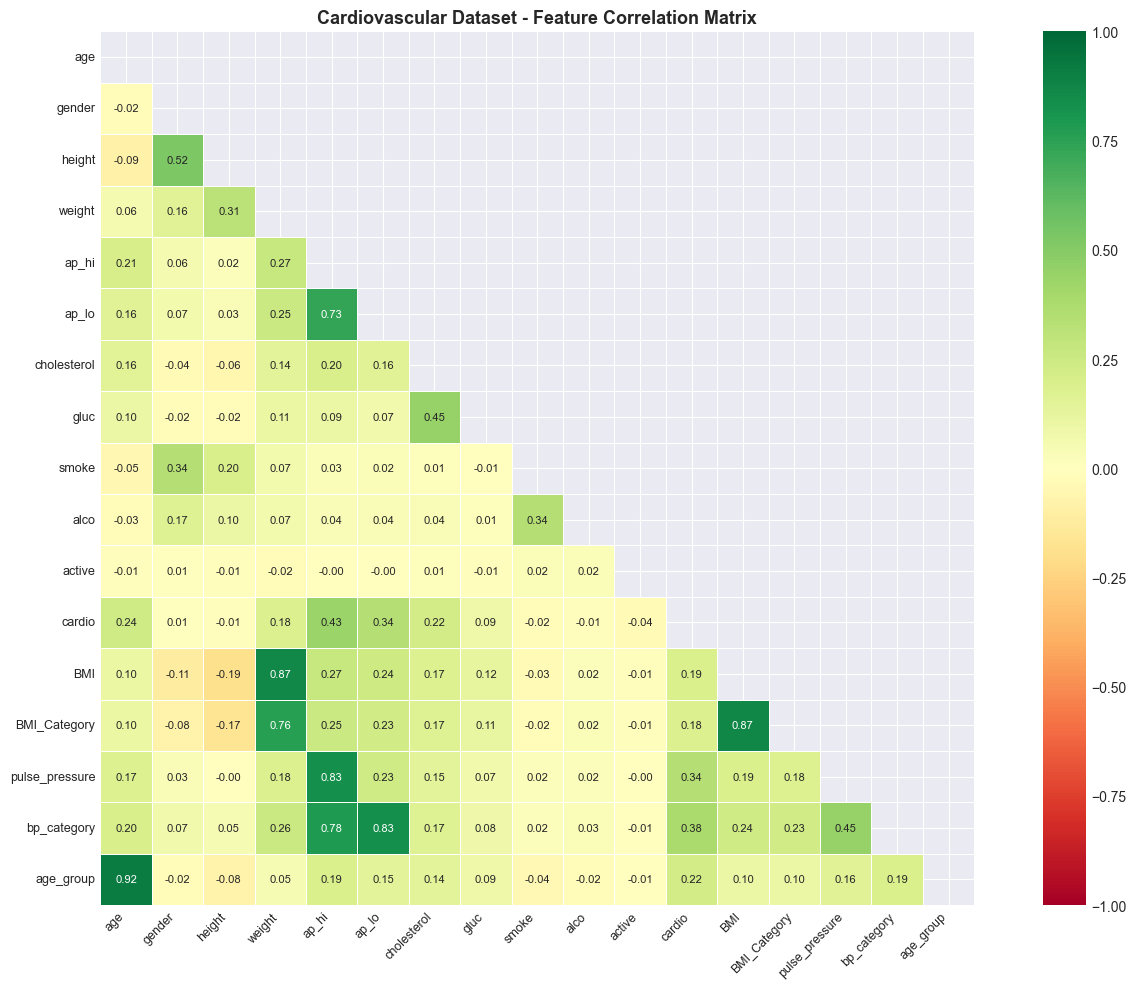

In [14]:
#  CELL 10: Correlation Analysis

plt.figure(figsize=(14, 10))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Cardiovascular Dataset - Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('../artifacts/cardio_correlation_hitmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# -- find the Correlation with target --------
print('Feature Correlation with Target (cardio)')

target_corr = corr['cardio'].drop('cardio')
target_corr = target_corr.abs().sort_values(ascending=False)

for feat, val in target_corr.items():
    direction = '+' if corr['cardio'][feat] > 0 else '-'
    bar= '|' * int(val*40)
    print(f" {feat:<20} {direction}{val:.3f} {bar}")
    
print(f"\n Top 5 : {list(target_corr.head(5).index)}")
print(f"Weak : {list(target_corr.tail(3).index)}") 

Feature Correlation with Target (cardio)
 ap_hi                +0.431 |||||||||||||||||
 bp_category          +0.376 |||||||||||||||
 ap_lo                +0.341 |||||||||||||
 pulse_pressure       +0.339 |||||||||||||
 age                  +0.239 |||||||||
 cholesterol          +0.221 ||||||||
 age_group            +0.220 ||||||||
 BMI                  +0.193 |||||||
 BMI_Category         +0.183 |||||||
 weight               +0.181 |||||||
 gluc                 +0.089 |||
 active               -0.038 |
 smoke                -0.016 
 height               -0.013 
 alco                 -0.009 
 gender               +0.007 

 Top 5 : ['ap_hi', 'bp_category', 'ap_lo', 'pulse_pressure', 'age']
Weak : ['height', 'alco', 'gender']


---
## 📊 Cell 10 — Correlation Analysis Findings

### Top 5 Predictors of Cardiovascular Disease
| Rank | Feature | Correlation | Clinical Meaning |
|------|---------|-------------|-----------------|
| 1 | `ap_hi` | +0.431 | Systolic BP — strongest single predictor |
| 2 | `bp_category` | +0.376 | Clinical threshold encoding of BP |
| 3 | `ap_lo` | +0.341 | Diastolic BP |
| 4 | `pulse_pressure` | +0.339 | Arterial stiffness marker |
| 5 | `age` | +0.239 | Age — universal cardiovascular risk factor |

### ⚠️ Multicollinearity Detected
| Pair | Correlation | Action |
|------|------------|--------|
| `ap_hi` ↔ `ap_lo` | 0.73 | Keep both — different clinical signals |
| `ap_hi` ↔ `bp_category` | 0.78 | Keep both — different representations |
| `BMI` ↔ `BMI_Category` | 0.87 | **Drop BMI_Category** |
| `age` ↔ `age_group` | 0.92 | **Drop age_group** |

### Features to Drop
- `age_group` — 0.92 correlation with `age` (nearly identical)
- `BMI_Category` — 0.87 correlation with `BMI`
- `gender`, `alco`, `smoke`, `height` — near-zero target correlation

### Final Feature Set (9 features)
`age`, `ap_hi`, `ap_lo`, `pulse_pressure`, `bp_category`,
`cholesterol`, `BMI`, `weight`, `gluc`, `active`
---

In [16]:
# ============================================================
# CELL 11: Final Feature Selection
# ============================================================

# Features to drop
drop_cols = ['age_group', 'BMI_Category',
             'gender', 'alco', 'smoke', 'height']

df_model = df.drop(columns=drop_cols)

print("=" * 55)
print(" FINAL DATASET FOR MODELING")
print("=" * 55)
print(f"\n Shape    : {df_model.shape}")
print(f"\n Features : {list(df_model.columns)}")
print(f"\n Target distribution:")
print(df_model['cardio'].value_counts())

# Verify no missing values
print(f"\n Missing values: {df_model.isnull().sum().sum()}")

# Quick stats
print(f"\n Feature summary:")
print(df_model.describe().round(2).T[
    ['mean', 'std', 'min', 'max']
].to_string())

 FINAL DATASET FOR MODELING

 Shape    : (68433, 11)

 Features : ['age', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'active', 'cardio', 'BMI', 'pulse_pressure', 'bp_category']

 Target distribution:
cardio
0    34595
1    33838
Name: count, dtype: int64

 Missing values: 0

 Feature summary:
                 mean   std   min    max
age             53.33  6.77 30.00  65.00
weight          74.08 14.20 30.00 200.00
ap_hi          126.59 16.47 70.00 200.00
ap_lo           81.27  9.34 40.00 130.00
cholesterol      1.36  0.68  1.00   3.00
gluc             1.23  0.57  1.00   3.00
active           0.80  0.40  0.00   1.00
cardio           0.49  0.50  0.00   1.00
BMI             27.42  5.16 10.70  59.50
pulse_pressure  45.32 11.56  5.00 135.00
bp_category      3.03  0.99  1.00   5.00


---
## 📊 Cell 11 — Final Dataset Summary

### Features Selected (12 → 10 features + 1 target)

| Feature | Type | Range | Kept/Dropped | Reason |
|---------|------|-------|-------------|--------|
| `age` | Continuous | 30-65 | ✅ Kept | +0.239 correlation |
| `weight` | Continuous | 30-200 | ✅ Kept | +0.181 correlation |
| `ap_hi` | Continuous | 70-200 | ✅ Kept | Strongest predictor +0.431 |
| `ap_lo` | Continuous | 40-130 | ✅ Kept | Independent diastolic signal |
| `cholesterol` | Ordinal | 1-3 | ✅ Kept | +0.221 correlation |
| `gluc` | Ordinal | 1-3 | ✅ Kept | +0.089 correlation |
| `active` | Binary | 0-1 | ✅ Kept | Protective factor -0.038 |
| `BMI` | Continuous | 10.7-59.5 | ✅ Kept | +0.193 correlation |
| `pulse_pressure` | Continuous | 5-135 | ✅ Kept | Unique arterial stiffness signal |
| `bp_category` | Ordinal | 1-5 | ✅ Kept | Clinical threshold encoding |
| `height` | Continuous | — | ❌ Dropped | -0.013 near-zero signal |
| `gender` | Binary | — | ❌ Dropped | +0.007 near-zero |
| `smoke` | Binary | — | ❌ Dropped | -0.016 near-zero |
| `alco` | Binary | — | ❌ Dropped | -0.009 near-zero |
| `age_group` | Ordinal | — | ❌ Dropped | 0.92 correlation with age |
| `BMI_Category` | Ordinal | — | ❌ Dropped | 0.87 correlation with BMI |

### Key Difference from Project 2
- **No SMOTE required** — dataset is 50.6% / 49.4% balanced
- **No scale_pos_weight** — no class imbalance to correct
- Model learns both classes equally from the start
---